In [ ]:
# Инициализация виртуального экрана для работы в окружениях без графического интерфейса
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

Starting virtual X frame buffer: Xvfb.


In [2]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
from IPython import display
%matplotlib inline

In [3]:
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")

state_size = env.observation_space.n
action_size = env.action_space.n

In [4]:
env.action_space

Discrete(4)

In [5]:
def q_table_init(state_size, action_size):
    q_table = np.zeros((state_size, action_size))
    return q_table

In [6]:
def choose_action(q_table, state, epsilon):
    if np.random.random() < epsilon: #рандомное взятие
      return env.action_space.sample()
    else:
      action = np.argmax(q_table[state, :])
    return action


In [ ]:
def get_new_q_value(q_table, state, action, reward, next_state, gamma, alpha):

    new_value = q_table[state, action] + alpha * (reward + gamma * np.max(q_table[next_state, :]) - q_table[state, action])
    return new_value



In [8]:
def get_new_epsilon(epsilon, min_epsilon):
  return max(epsilon * epsilon_decay, min_epsilon)

In [ ]:
# Хранилище Q-значений для всех пар состояние-действие
Q_table = q_table_init(state_size, action_size)

# Параметры алгоритма обучения
alpha = 0.1  # Шаг обновления (скорость обучения)
gamma = 0.99  # Фактор обесценивания будущих наград
epsilon = 1.0  # Начальный уровень исследования (полностью случайный выбор)
epsilon_decay = 0.995  # Коэффициент экспоненциального затухания epsilon
min_epsilon = 0.01  # Нижняя граница исследования (минимальный случайный выбор)

episodes = 2000  # Общее количество обучающих итераций
max_steps = 100  # Лимит шагов на один эпизод (предотвращает бесконечные циклы)

# Журнал наград для анализа прогресса обучения
rewards = []

Эпизод: 200, средняя награда: 0.185, epsilon: 0.367
Эпизод: 400, средняя награда: 0.69, epsilon: 0.135
Эпизод: 600, средняя награда: 0.905, epsilon: 0.049
Эпизод: 800, средняя награда: 0.98, epsilon: 0.018
Эпизод: 1000, средняя награда: 0.995, epsilon: 0.010
Эпизод: 1200, средняя награда: 0.985, epsilon: 0.010
Эпизод: 1400, средняя награда: 0.985, epsilon: 0.010
Эпизод: 1600, средняя награда: 0.995, epsilon: 0.010
Эпизод: 1800, средняя награда: 0.995, epsilon: 0.010
Эпизод: 2000, средняя награда: 1.0, epsilon: 0.010


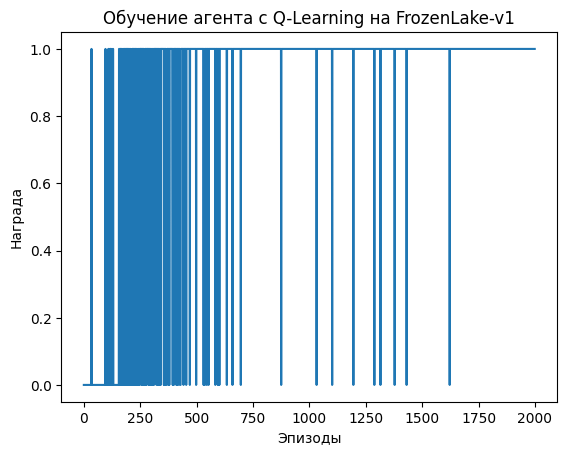

In [ ]:
# Основной цикл обучения
for episode in range(episodes):
    # Начало нового эпизода
    state = env.reset()[0]
    episode_reward = 0
    
    # Проход по шагам внутри эпизода
    for step in range(max_steps):
        # Стратегия epsilon-жадности: выбор между исследованием и использованием
        action = choose_action(Q_table, state, epsilon)

        # Взаимодействие со средой
        next_state, reward, done, _, _ = env.step(action)

        # Коррекция Q-значения на основе полученного опыта
        Q_table[state, action] = get_new_q_value(Q_table, state, action, reward, next_state, gamma, alpha)

        # Аккумулирование награды и переход в новое состояние
        episode_reward += reward
        state = next_state

        # Проверка завершения эпизода
        if done:
            break

    # Постепенное снижение уровня исследования
    epsilon = get_new_epsilon(epsilon, min_epsilon)
    
    # Сохранение результата эпизода
    rewards.append(episode_reward)

    # Периодический вывод метрик обучения
    if (episode + 1) % 200 == 0:
        recent_performance = np.mean(rewards[-200:])
        print(f"Эпизод: {episode + 1}, средняя награда: {recent_performance:.3f}, epsilon: {epsilon:.3f}")

# Визуализация кривой обучения
plt.figure(figsize=(10, 5))
plt.plot(range(episodes), rewards, alpha=0.6, linewidth=0.8)
plt.xlabel("Номер эпизода обучения")
plt.ylabel("Суммарная награда за эпизод")
plt.title("Динамика обучения агента методом Q-Learning")
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# Тестирование обученного агента

test_episodes = 5
for episode in range(test_episodes):
    state = env.reset()[0]
    done = False
    truncated = False
    total_reward = 0
    while not (done or truncated):
        action = choose_action(Q_table, state, 0)
        state, reward, done, truncated, _ = env.step(action)
        total_reward += reward
    print(f"Эпизод {episode + 1}: Общая награда = {total_reward}")

env.close()

Эпизод 1: Общая награда = 1
Эпизод 2: Общая награда = 1
Эпизод 3: Общая награда = 1
Эпизод 4: Общая награда = 1
Эпизод 5: Общая награда = 1


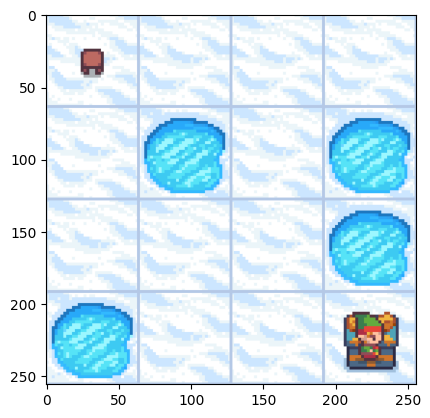

In [ ]:
display.clear_output(wait=True)
state = env.reset()[0]
done = False
total_reward = 0
print(f"Эпизод {episode + 1}:")
while not done:
    action = choose_action(Q_table, state, 0)
    state, reward, done, _, _ = env.step(action)
    total_reward += reward
    plt.imshow(env.render())

    display.display(plt.gcf())
    display.clear_output(wait=True)